# Extended Data Figs. 26-28 - Practical multi-section 2D sampling and 2D-recall analysis

Extended Data Figs. 26, 27 and 28 apply the **same set of 2D-sampling analyses** to different datasets (ED26: AppNL-G-F time-course; ED27: WT 5 months; ED28: VCP and AppNL-G-F models) and to optical vs physical sections. Because the analysis code is identical across these cases, **one representative case of each analysis type is shown here**; the same code was rerun on the other models/sections for the respective figure panels.

Two practical sampling protocols are emulated from the 3D whole-brain reference: Protocol 1 (random coronal sections, whole-slide coverage) and Protocol 2 (uniform-interval coronal sections, stereology-style).

Analyses (one representative case each):
1. Regional density correlation: 2D-estimated vs 3D reference density across 671 regions.
2. Measurement variability: Normalized Average CV2D (3D CV3D = 1.0) vs sampling density.
3. Sampling density required to estimate 3D density within <=10% error (cumulative across regions).
4. Detection sensitivity: Average 2D Recall vs sampling density (e.g. neuronal decrease: App 0.20 at 5 sections).
5. Statistical test: multiple linear regression showing 2D recall is significantly predicted by CV2D.

> Figures and key numeric outputs preserved from the original runs; Japanese stripped from comments; verbose logs removed.

## Input files

| File | Content |
|---|---|
| optically-derived per-section regional densities / per-trial 2D-sampled region sets | Protocol 1/2 samples |
| 3D whole-brain reference regional densities (671 regions) | reference (CV3D=1.0) |
| `Combined_recall_vs_slice_number_data_*.csv`, `Recall_vs_SamplingSpan_*` | recall summaries |
| required-sections / CV / %SD summary tables | <=10% error & regression inputs |

## 1. Regional density correlation: 2D-estimated vs 3D reference (representative: WT, Protocol 1, NeuN)

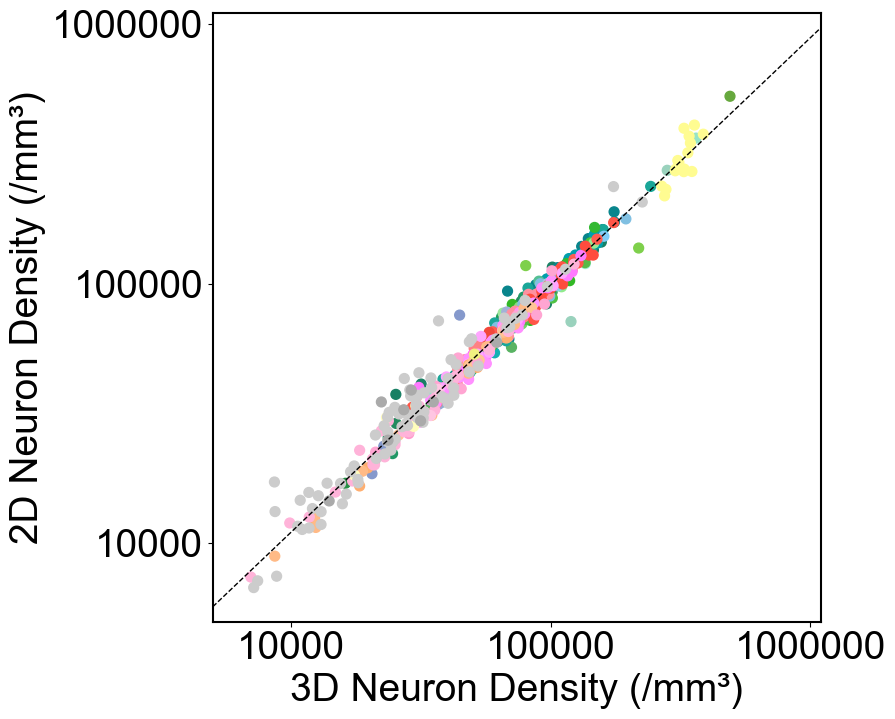

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from scipy.stats import spearmanr
import os
import matplotlib.ticker as mticker

#
GROUP_TO_ANALYZE = "WT_5m"
TARGET_CELL_TYPE = "neun"
SLICE_NUM_TO_CALCULATE = 5

#
DATA_PATH = "/export3/Imaging/ds4_Data5/Neurology_project_data_archive/mitani/Neurology/Rebuttal Figures/"
#
COLOR_MAP_PATH = "/export3/Imaging/atlas_for_fig/GOvsID_6region_removed.csv" 

#
if __name__ == "__main__":
    #

    all_atlas_ids = data_GO['id'].unique().tolist()

    #
    input_filename = os.path.join(
        DATA_PATH,
        f"mean_3d_vs_2d_{GROUP_TO_ANALYZE}_{TARGET_CELL_TYPE}_{SLICE_NUM_TO_CALCULATE}slices.csv"
    )

    try:
        df = pd.read_csv(input_filename, index_col='region_id')
    except FileNotFoundError:
        print(f"ERROR: Input file not found at {input_filename}")
        exit()

    #
    df = df.reindex(all_atlas_ids, fill_value=0)
    #
    df = df.fillna(0) 

    #
    if not df.empty:
        corr, p_value = spearmanr(df['3d_mean'], df['2d_mean'])
        print(f"\nSpearman Correlation (including zeros): {corr:.4f}")
        print(f"P-value: {p_value:.4g}")
    else:
        print("\nCould not calculate correlation because the dataframe is empty.")

    #
    #
    df_for_plot = df[(df['3d_mean'] > 0) & (df['2d_mean'] > 0)].copy()
    print(f"\nTotal regions in data: {len(df)}. Regions for plotting (non-zero): {len(df_for_plot)}")
    #

    #
    try:
        color_df = pd.read_csv(COLOR_MAP_PATH)
        color_df = color_df[['id', 'R', 'G', 'B']]
        color_df['color'] = color_df.apply(lambda row: (row['R']/255, row['G']/255, row['B']/255), axis=1)
        df_for_plot = df_for_plot.merge(color_df[['id', 'color']], left_index=True, right_on='id', how='left')
        df_for_plot['color'] = df_for_plot['color'].apply(lambda x: (0.7, 0.7, 0.7) if pd.isnull(x) else x)
        print("Successfully merged color map.")
        
    except FileNotFoundError:
        print(f"WARNING: Color map file not found at {COLOR_MAP_PATH}. All points will be blue.")
        df_for_plot['color'] = 'royalblue'

    if df_for_plot.empty:
        print("ERROR: The dataframe for plotting is empty after filtering for non-zero values. Cannot plot.")
        #
        # exit()

    #
    plt.style.use('default')
    matplotlib.rcParams['pdf.fonttype'] = 42
    matplotlib.rcParams['font.family'] = 'Arial'
    matplotlib.rcParams['axes.linewidth'] = 1.5
    fig, ax = plt.subplots(figsize=(9, 9))

    min_val_axis = 5000 
    max_val_axis = 1000000 * 1.1

    if not df_for_plot.empty:
        ax.scatter(
            df_for_plot['3d_mean'],
            df_for_plot['2d_mean'],
            alpha=1,
            s=50,
            c=df_for_plot['color']
        )
        
        log_3d = np.log10(df_for_plot['3d_mean'])
        log_2d = np.log10(df_for_plot['2d_mean'])
        m, c = np.polyfit(log_3d, log_2d, 1)
        
        x_fit = np.array([min_val_axis, max_val_axis])
        y_fit = 10**(m * np.log10(x_fit) + c)
        
        ax.plot(x_fit, y_fit, color='black', linewidth=1, linestyle='--')

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('3D Neuron Density (/mm³)', fontsize=28)
    ax.set_ylabel('2D Neuron Density (/mm³)', fontsize=28)
    ax.tick_params(axis='both', which='major', labelsize=28)
    ax.set_xlim(min_val_axis, max_val_axis)
    ax.set_ylim(min_val_axis, max_val_axis)
    ax.set_aspect('equal', adjustable='box')
    
    major_ticks = [10000, 100000, 1000000]
    ax.set_xticks(major_ticks)
    ax.set_yticks(major_ticks)

    for axis in [ax.xaxis, ax.yaxis]:
        axis.set_major_formatter(mticker.ScalarFormatter())
        axis.get_major_formatter().set_scientific(False)
        axis.set_minor_locator(mticker.NullLocator())

    plt.tight_layout()
    
    #
    #
    #
    output_filename_base = f"correlation_3d_vs_2d_{GROUP_TO_ANALYZE}_{TARGET_CELL_TYPE}_{SLICE_NUM_TO_CALCULATE}slices"
    
    #
    csv_output_filename = os.path.join(DATA_PATH, f"{output_filename_base}_colored_loglog.csv")
    df.to_csv(csv_output_filename, index_label='region_id')
    print(f"\nComplete DataFrame (all regions) saved to: {csv_output_filename}")

    #
    pdf_output_filename = os.path.join(DATA_PATH, f"{output_filename_base}_colored_loglog.pdf")
    plt.savefig(pdf_output_filename, transparent=True, dpi=300)
    print(f"Plot saved to: {pdf_output_filename}")
    plt.show()
    #


## 2. Measurement variability: Normalized CV2D vs sampling density (representative: AppNL-G-F, Protocol 1)

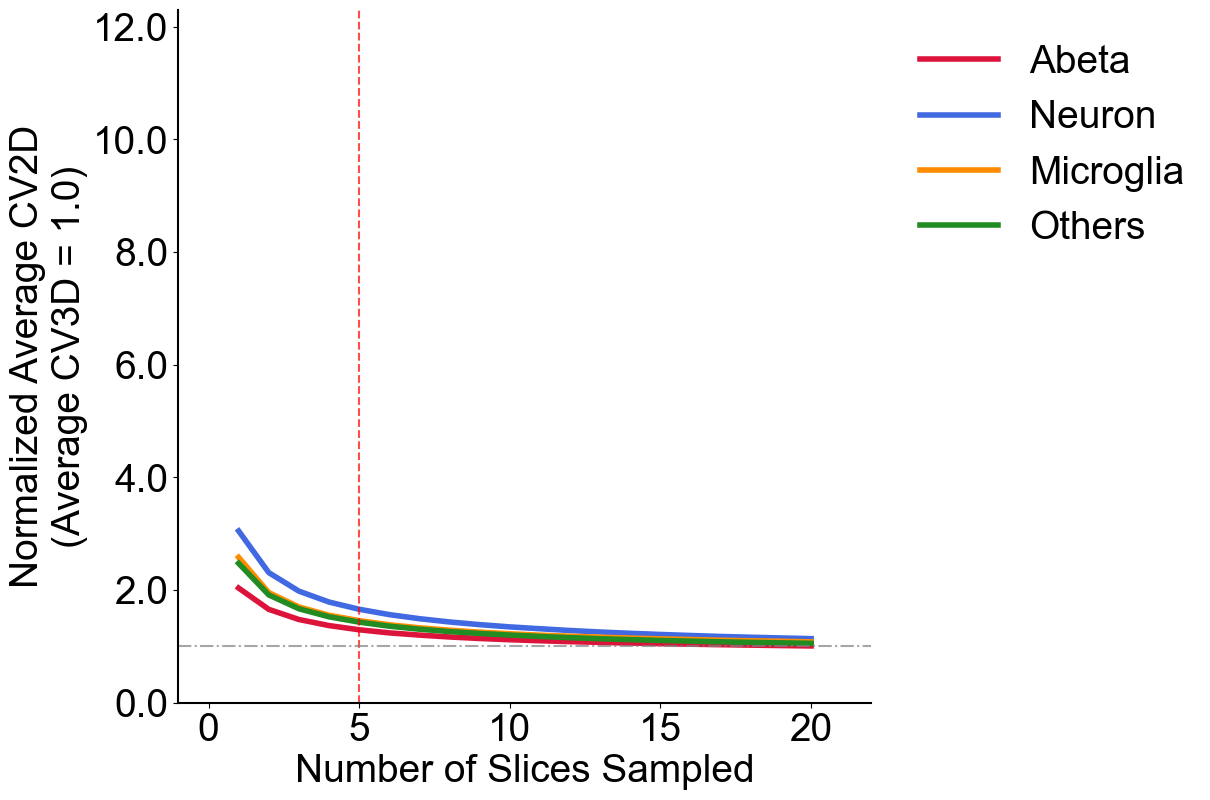

In [2]:
# 250901
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.ticker as mticker

#
GROUP_TO_ANALYZE = "APP_9m" #  

cell_types_to_plot = {
    "Abeta":   {"file_tag": "abeta",   "color": "crimson",   "label": "Abeta"},
    "NeuN":   {"file_tag": "neun",   "color": "royalblue",   "label": "Neuron"},
    "Iba1":   {"file_tag": "iba1",   "color": "darkorange",  "label": "Microglia"},
    "Others": {"file_tag": "others", "color": "forestgreen", "label": "Others"}
}

#
output_base_path = "/export3/Imaging/ds4_Data5/Neurology_project_data_archive/mitani/Neurology/Rebuttal Figures/"
output_pdf_path = os.path.join(output_base_path, f"Rescaled_Raw_cv_2D_vs_slice_count_{GROUP_TO_ANALYZE}_filtered.pdf")
#
output_csv_path = os.path.join(output_base_path, f"cv_analysis_vs_slice_count_{GROUP_TO_ANALYZE}_summary.csv")


#
if __name__ == "__main__":
    
    #
    all_results_df = pd.DataFrame()

    #
    plt.style.use('default')
    matplotlib.rcParams['pdf.use14corefonts'] = True
    matplotlib.rcParams['font.family'] = 'Arial'
    matplotlib.rcParams['axes.linewidth'] = 1.5
    fig, ax = plt.subplots(figsize=(9, 9))

    #
    for cell_type, params in cell_types_to_plot.items():
        filename = os.path.join(output_base_path, f"cv_analysis_vs_slice_count_{GROUP_TO_ANALYZE}_{params['file_tag']}.csv")
        try:
            df = pd.read_csv(filename, index_col='region_id')
            
            #
            df_raw_cv = df.filter(like='_raw_cv')
            s_3d_cv = df['3d_cv']
            mean_3d_cv = s_3d_cv.mean()
            df_scaled_cv = df_raw_cv / mean_3d_cv
            
            df_scaled_cv.columns = df_scaled_cv.columns.str.replace('slices_', '').str.replace('_raw_cv', '').astype(int)
            
            mean_scaled_cv = df_scaled_cv.mean(axis=0)
            std_scaled_cv = df_scaled_cv.std(axis=0)

            #
            mean_to_plot = mean_scaled_cv.loc[1:20]
            std_to_plot = std_scaled_cv.loc[1:20]
            
            #
            df_temp_results = pd.DataFrame({
                'Number of Slices': mean_to_plot.index,
                'Mean Scaled CV': mean_to_plot.values,
                'Std Scaled CV': std_to_plot.values
            })
            df_temp_results['Cell Type'] = params['label']
            
            #
            all_results_df = pd.concat([all_results_df, df_temp_results], ignore_index=True)


            #
            ax.plot(mean_to_plot.index, mean_to_plot.values,
                    linewidth=4,
                    color=params['color'],
                    label=params['label'])
            
            ax.fill_between(
                std_to_plot.index,
                (mean_to_plot - std_to_plot),
                (mean_to_plot + std_to_plot),
                color=params['color'],
                alpha=0.0
            )

        except (FileNotFoundError, KeyError) as e:
            print(f"WARNING: Could not process {filename}. Reason: {e}")
            continue

    #
    ax.set_xlabel('Number of Slices Sampled', fontsize=28)
    ax.set_ylabel('Normalized Average CV2D\n(Average CV3D = 1.0)', fontsize=28)
    ax.tick_params(axis='both', which='major', labelsize=28)
    ax.axvline(x=5, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
    ax.axhline(y=1.0, color='gray', linestyle='dashdot', linewidth=1.5, alpha=0.7)
    ax.set_ylim(bottom=0, top=12.3)
    ax.set_xlim(left=-1, right=22)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    formatter = mticker.FormatStrFormatter('%.1f')
    ax.yaxis.set_major_formatter(formatter)
    x_range = ax.get_xlim()[1] - ax.get_xlim()[0]
    y_range = ax.get_ylim()[1] - ax.get_ylim()[0]
    ax.set_aspect(aspect=x_range/y_range, adjustable='box')
    ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=28, frameon=False)

    #
    #
    plt.savefig(output_pdf_path, transparent=True, dpi=300, bbox_inches='tight', pad_inches=0.1)
    print(f"\nPlot saved to: {output_pdf_path}")
    
    #
    all_results_df.to_csv(output_csv_path, index=False)
    print(f"Results summary saved to: {output_csv_path}")

    plt.show()

## 3. Sampling density required to estimate 3D density within <=10% error (cumulative across regions)

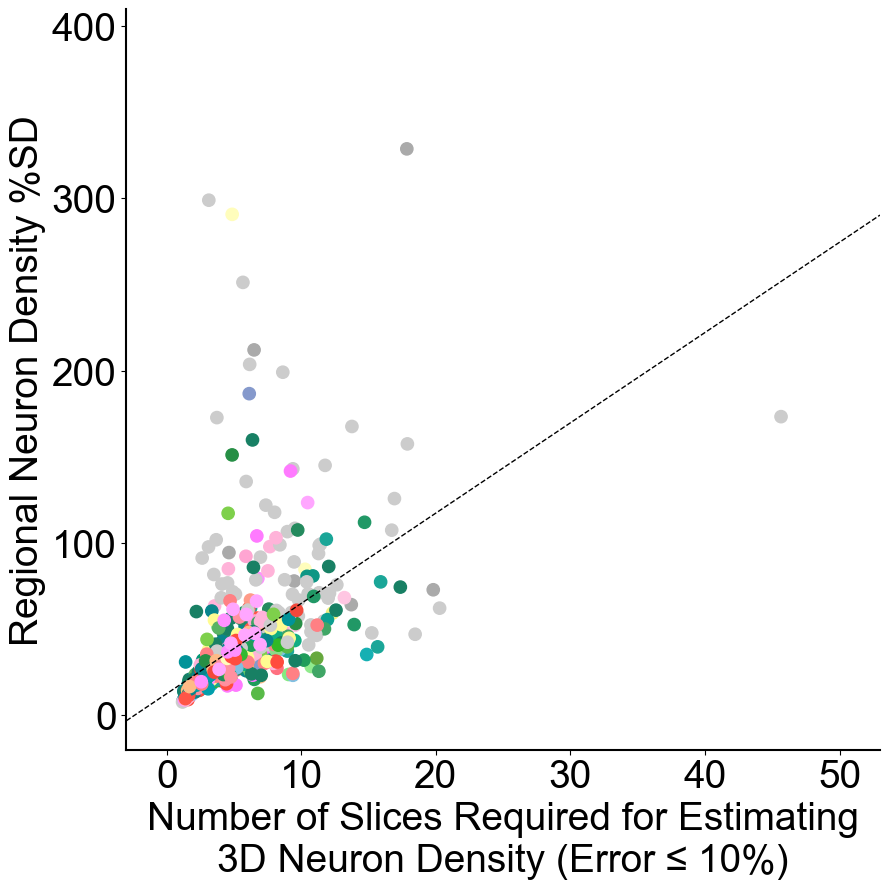

In [3]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib
from scipy.stats import spearmanr

#
#
GROUP_TO_ANALYZE = "WT_5m"
TARGET_CELL_TYPE = "neun" # neun, iba1, others

#
#
DATA_PATH = "/export3/Imaging/ds4_Data5/Neurology_project_data_archive/mitani/Neurology/Rebuttal Figures/"
#
NAIVE_SD_FILE = "/export3/Imaging/ds4_Data4/Neurology_project_data_archive/Cellome/Naive_Cell_Distribution_SD_5m.csv"
#
COLOR_MAP_PATH = "/export3/Imaging/atlas_for_fig/GOvsID_6region_removed.csv" 

#
if __name__ == "__main__":
    #
    coverage_filename = os.path.join(
        DATA_PATH,
        f"cumulative_coverage_data_{GROUP_TO_ANALYZE}_{TARGET_CELL_TYPE}.csv"
    )
    try:
        #
        df_coverage = pd.read_csv(coverage_filename, index_col=0)
        #
        required_slices = df_coverage['group_mean']
        print(f"Successfully loaded required slices data from: {coverage_filename}")
    except FileNotFoundError:
        print(f"ERROR: Required slices file not found at {coverage_filename}")
        exit()

    #
    try:
        #
        df_sd = pd.read_csv(NAIVE_SD_FILE, index_col=0)
        
        #
        if TARGET_CELL_TYPE == 'neun':
            sd_column_name = 'NeuN_5m'
        else:
            sd_column_name = f"{TARGET_CELL_TYPE.capitalize()}_5m"

        density_sd = df_sd[sd_column_name]
        print(f"Successfully loaded density SD data from: {NAIVE_SD_FILE}")
    except (FileNotFoundError, KeyError) as e:
        print(f"ERROR: Could not load or find column in SD file: {e}")
        exit()

    #
    df_merged = pd.DataFrame({
        'required_slices': required_slices,
        'density_sd': density_sd
    })
    
    #
    df_merged.dropna(inplace=True)

    #
    try:
        color_df = pd.read_csv(COLOR_MAP_PATH)
        color_df['color'] = color_df.apply(lambda row: (row['R']/255, row['G']/255, row['B']/255), axis=1)
        #
        df_merged = df_merged.merge(color_df[['id', 'color']], left_index=True, right_on='id', how='left')
        
        #
        df_merged['color'] = df_merged['color'].apply(lambda x: (0.7, 0.7, 0.7) if pd.isnull(x) else x)
        print("Successfully merged color map.")
        
    except FileNotFoundError:
        print(f"WARNING: Color map file not found at {COLOR_MAP_PATH}. All points will be plotted in a single color.")
        df_merged['color'] = 'royalblue'

    #
    corr, p_value = 0, 1
    if not df_merged.empty:
        corr, p_value = spearmanr(df_merged['required_slices'], df_merged['density_sd'])
        print(f"\nSpearman Correlation: {corr:.4f}, P-value: {p_value:.4g}")
    else:
        print("\nCould not calculate correlation because the merged dataframe is empty.")
        
    #
    plt.style.use('default')
    matplotlib.rcParams['pdf.fonttype'] = 42
    matplotlib.rcParams['font.family'] = 'Arial'
    matplotlib.rcParams['axes.linewidth'] = 1.5
    fig, ax = plt.subplots(figsize=(9, 9))

    if not df_merged.empty:
        ax.scatter(
            df_merged['required_slices'],
            df_merged['density_sd'],
            alpha=1.0,
            s=78,
            c=df_merged['color']
        )

        #
        m, c = np.polyfit(df_merged['required_slices'], df_merged['density_sd'], 1)
        
        #
        ax.set_xlabel('Number of Slices Required for Estimating\n3D Neuron Density (Error ≤ 10%)', fontsize=28)
        ax.set_ylabel(f'Regional Neuron Density %SD', fontsize=28)
        ax.tick_params(axis='both', which='major', labelsize=28)
        
        ax.set_xlim(-3, 53)
        ax.set_ylim(-20, 410)
        
        #
        #
        ax.set_xticks([0, 10, 20, 30, 40, 50])
        ax.set_yticks([0, 100, 200, 300, 400])
        #

        #
        x_vals = np.array(ax.get_xlim())
        y_vals = c + m * x_vals
        ax.plot(x_vals, y_vals, color='black', linestyle='--', linewidth=1)

    #
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    
    #
    output_filename = os.path.join(
        DATA_PATH,
        f"required_slices_vs_density_sd_{GROUP_TO_ANALYZE}_{TARGET_CELL_TYPE}.pdf"
    )
    plt.savefig(output_filename, transparent=True, dpi=300)
    
    print(f"\nPlot saved to: {output_filename}")
    plt.show()



## 4. Detection sensitivity: Average 2D Recall vs sampling density (representative: AppNL-G-F, Protocol 1)

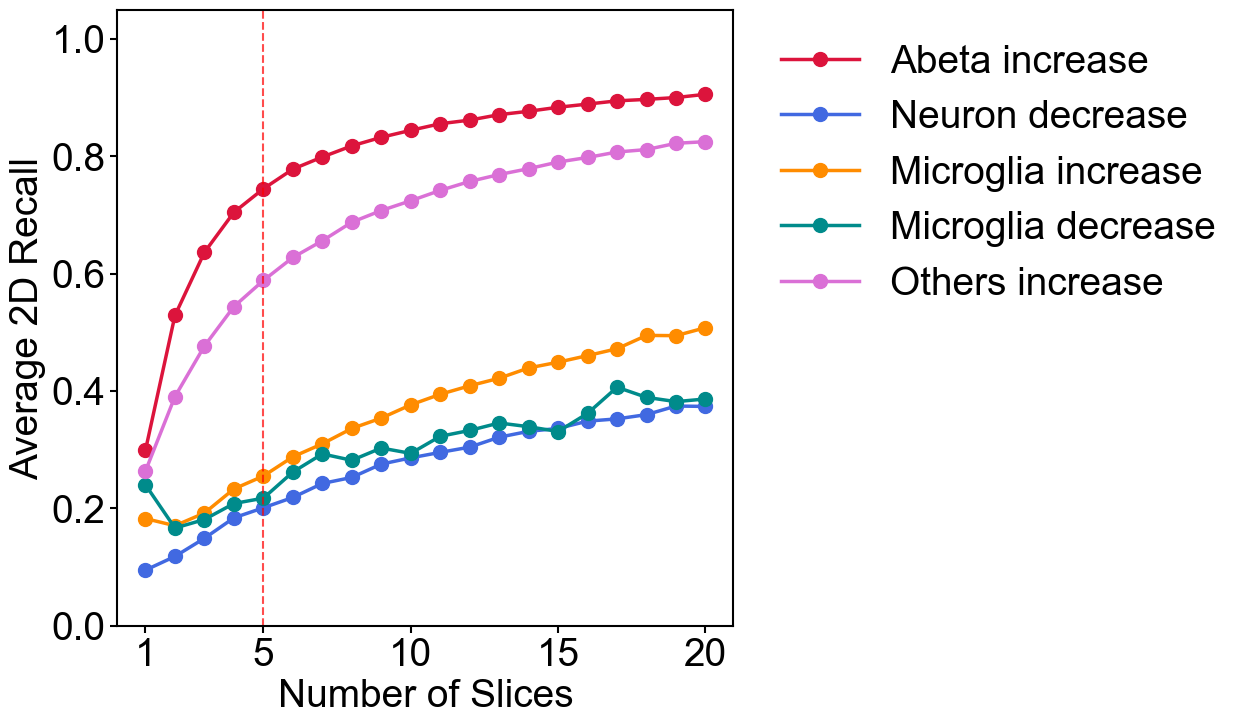

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import concurrent.futures
import os
from datetime import datetime

#
def process_slice(args):
    """
    1 100 Recall 
     Recall 
    """
    #
    condition_name, params, slice_num, ground_truth_regions = args
    file_tag = params['file_tag']
    
    #
    if not ground_truth_regions:
        return (condition_name, slice_num, np.nan)
        
    total_positives = len(ground_truth_regions)
    recalls_for_current_slice = []

    #
    for t in range(100):
        #
        filepath = f'/export3/Imaging/ds4_Data4/Neurology_project_data_archive/Region/WT_9m_vs_APP_9m_raw_value_regions_glm_ver_{file_tag}_random_slice_{slice_num}_trial_{t}.csv'
        
        try:
            #
            predicted_df = pd.read_csv(filepath, index_col='atlasID')
            predicted_regions = set(predicted_df.index)
        except FileNotFoundError:
            continue #  

        #
        #
        true_positives = len(ground_truth_regions.intersection(predicted_regions))
        
        #
        recall = true_positives / total_positives
        recalls_for_current_slice.append(recall)

    if recalls_for_current_slice:
        avg_recall = np.mean(recalls_for_current_slice)
        return (condition_name, slice_num, avg_recall)
    else:
        #
        return (condition_name, slice_num, np.nan)

#
def main(conditions):
    """ Recall """
    
    #
    ground_truths = {}
    print("Loading ground truth files...")
    for condition_name, params in conditions.items():
        file_tag = params['file_tag']
        #
        gt_filepath = f'/export3/Imaging/ds4_Data4/Neurology_project_data_archive/Region/WT_9m_vs_APP_9m_raw_value_regions_{file_tag}.csv'
        try:
            gt_df = pd.read_csv(gt_filepath, index_col='atlasID')
            #
            ground_truths[condition_name] = set(gt_df.index)
            print(f" -> Found {len(ground_truths[condition_name])} regions for '{condition_name}'")
        except FileNotFoundError:
            print(f" -> WARNING: Ground truth file not found for '{condition_name}'. Skipping.")
            ground_truths[condition_name] = set() #  

    #
    slice_numbers = range(1, 21)
    tasks = []
    for condition_name, params in conditions.items():
        #
        if ground_truths[condition_name]:
            for slice_num in slice_numbers:
                tasks.append((condition_name, params, slice_num, ground_truths[condition_name]))
    
    #
    results_dict = {name: [np.nan] * len(slice_numbers) for name in conditions.keys()}
    print(f"\n[{datetime.now().strftime('%H:%M:%S')}] Starting parallel processing for {len(tasks)} tasks...")
    with concurrent.futures.ProcessPoolExecutor(max_workers=5) as executor:
        future_to_task = {}
        for task in tasks:
            future = executor.submit(process_slice, task)
            task_info = f"{task[0]} - Slice {task[2]}"
            future_to_task[future] = task_info
        for future in concurrent.futures.as_completed(future_to_task):
            task_info = future_to_task[future]
            try:
                res_condition, res_slice, res_recall = future.result()
                results_dict[res_condition][res_slice - 1] = res_recall
                print(f"[{datetime.now().strftime('%H:%M:%S')}] Finished: {task_info}, Avg Recall: {res_recall:.4f}")
            except Exception as exc:
                print(f"[{datetime.now().strftime('%H:%M:%S')}] ERROR: {task_info} generated an exception: {exc}")
    print(f"[{datetime.now().strftime('%H:%M:%S')}] All processing finished!")
    return results_dict

#
if __name__ == "__main__":
    #
    conditions_to_run = {
        'Abeta increase':    {'file_tag': 'Abeta_increase', 'color': 'crimson'},
        'Neuron decrease':    {'file_tag': 'NeuN_decrease', 'color': 'royalblue'},
        'Microglia increase': {'file_tag': 'Iba1_increase', 'color': 'darkorange'},
        'Microglia decrease': {'file_tag': 'Iba1_decrease', 'color': 'darkcyan'},
        'Others increase':    {'file_tag': 'others_increase', 'color': 'orchid'}
    }


    #
    #
    new_results = main(conditions_to_run)
    #
    #
    results_df = pd.DataFrame(new_results)
    
    #
    slice_numbers = range(1, 21)
    results_df['Number of Slices'] = slice_numbers
    
    #
    cols = ['Number of Slices'] + [col for col in results_df.columns if col != 'Number of Slices']
    results_df = results_df[cols]

    #
    output_csv_path = '/export3/Imaging/ds4_Data5/Neurology_project_data_archive/mitani/Neurology/Rebuttal Figures/Combined_recall_vs_slice_number_data_WT_9m_vs_APP_9m.csv'
    results_df.to_csv(output_csv_path, index=False)
    print(f"\nPlotting data saved to: {output_csv_path}")
    # ★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★
    #
    print("\nPlotting results...")
    slice_numbers = range(1, 21)
    plt.style.use('default')
    matplotlib.rcParams['pdf.use14corefonts'] = True
    plt.rcParams['font.family'] = 'Arial'
    plt.rcParams['axes.linewidth'] = 1.5
    fig, ax = plt.subplots(figsize=(12, 8))

    #
    #
    for condition_name, recalls in new_results.items():
        if not np.isnan(recalls).all():
            ax.plot(slice_numbers, recalls,
                    marker='o', markersize=10, linestyle='-', linewidth=2.5,
                    color=conditions_to_run[condition_name]['color'], 
                    label=condition_name)
                    
    ax.axvline(x=5, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
    ax.set_xlabel('Number of Slices', fontsize=28)
    ax.set_ylabel('Average 2D Recall', fontsize=28)
    ax.set_xticks([1, 5, 10, 15, 20])
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis='both', which='major', labelsize=28)
    ax.tick_params(direction='out', width=1.5, length=5)
    ax.set_aspect(aspect=(ax.get_xlim()[1]-ax.get_xlim()[0])/(ax.get_ylim()[1]-ax.get_ylim()[0]), adjustable='box')
    ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=28, frameon=False)
    plt.savefig('/export3/Imaging/ds4_Data5/Neurology_project_data_archive/mitani/Neurology/Rebuttal Figures/Combined_recall_vs_slice_number_parallel_WT_9m_vs_APP_9m.pdf',
                transparent=True, dpi=300, bbox_inches='tight', pad_inches=0.1)
    plt.show()

In [5]:
import pandas as pd

csv_path = '/export3/Imaging/ds4_Data5/Neurology_project_data_archive/mitani/Neurology/Rebuttal Figures/Combined_recall_vs_slice_number_data_WT_9m_vs_APP_9m.csv'

results_df = pd.read_csv(csv_path)

row = results_df[results_df['Number of Slices'] == 5].iloc[0]

print("\n--- Values at Slice Number = 5 ---")
for condition, value in row.items():
    if condition != 'Number of Slices':
        print(f"  {condition:25s}: {value:.4f}")



--- Values at Slice Number = 5 ---
  Abeta increase           : 0.7446
  Neuron decrease          : 0.2009
  Microglia increase       : 0.2550
  Microglia decrease       : 0.2173
  Others increase          : 0.5884


## 5. Statistical test: 2D recall predicted by CV2D (multiple linear regression, R lm)

Successfully loaded and combined CV data.
Successfully loaded Recall data.

--- Linear Regression Results (Recall ~ Category + CV) ---

--- R lm() Key Results ---
Overall Coefficient for CV: -0.0570
Overall P-value for CV: 0.0000
R-squared: 0.9003
Overall model shows significant decrease with CV: True


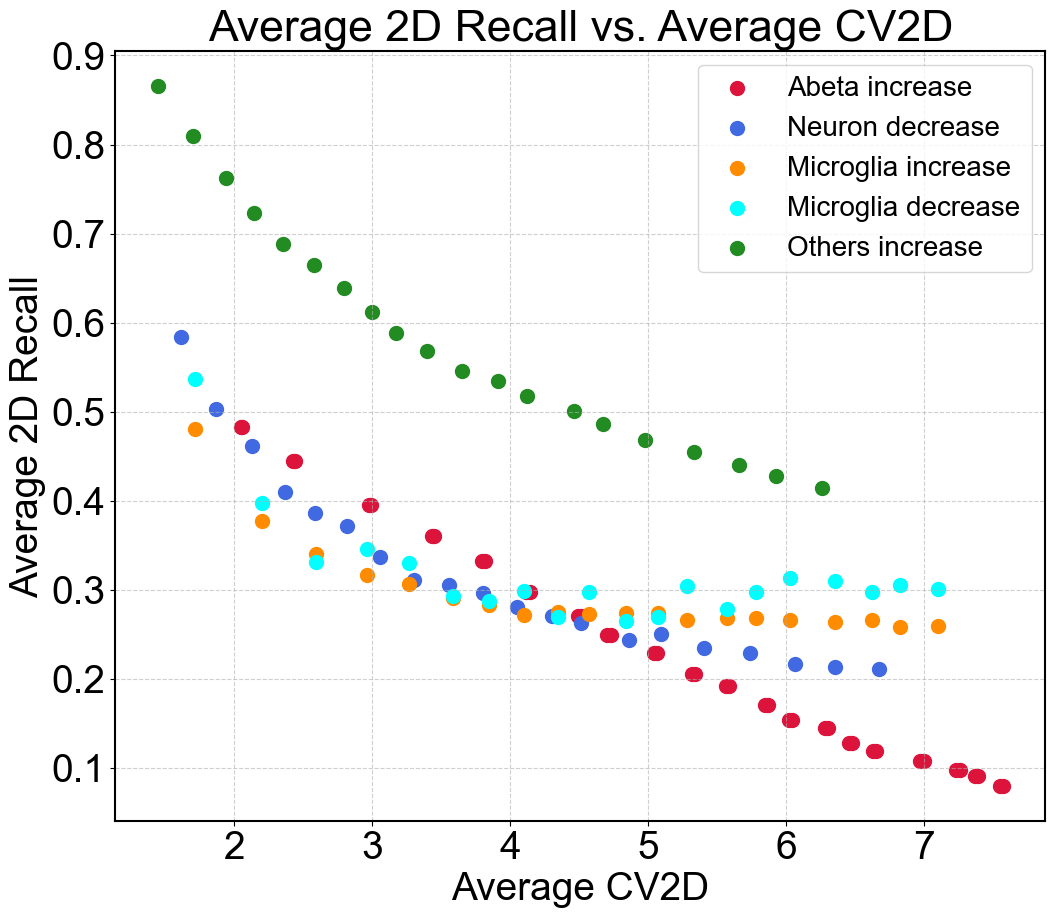


Plot saved to: /export3/Imaging/ds4_Data5/Neurology_project_data_archive/mitani/Neurology/Rebuttal Figures/Recall_vs_CV_Regression_Plot.pdf


In [6]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib
from scipy.stats import spearmanr, pearsonr
import statsmodels.formula.api as smf

#
try:
    import rpy2.robjects as robjects
    from rpy2.robjects import pandas2ri
    
    #
    r = robjects.r
    pandas2ri.activate()
    #
    r('library(stats)')

    def run_linear_regression(data):
        """rpy2 R lm """
        try:
            #
            robjects.globalenv['data'] = pandas2ri.py2rpy(data)
            #
            r_code = '''
            model <- lm(`Average 2D recall` ~ `Original Cell Type` + `Average CV2D`, data = data)
            summary_model <- summary(model)
            #
            coef <- summary_model$coefficients["`Average CV2D`", "Estimate"]
            p_value <- summary_model$coefficients["`Average CV2D`", "Pr(>|t|)"]
            r_squared <- summary_model$r.squared
            c(coef, p_value, r_squared)
            '''
            results = robjects.r(r_code)
            return results[0], results[1], results[2]
        except Exception as e:
            print(f"R Linear Regression Error: {e}")
            return None, None, None
            
except ImportError:
    print("Warning: rpy2 library not found. The run_linear_regression function will not work.")
    def run_linear_regression(data):
        print("Error: rpy2 is not installed.")
        return None, None, None

#
base_path = '/export3/Imaging/ds4_Data5/Neurology_project_data_archive/mitani/Neurology/Rebuttal Figures/'
recall_csv_path = os.path.join(base_path, 'Recall_vs_SamplingSpan_Stereology_Summary_WT_9m_vs_APP_9m.csv')
cv_main_csv_path = os.path.join(base_path, 'normalized_cv_results_APP_9m.csv')
cv_abeta_csv_path = os.path.join(base_path, 'normalized_cv_results_APP_9m_abeta.csv')

#
#
try:
    df_cv_main = pd.read_csv(cv_main_csv_path)
    df_cv_abeta = pd.read_csv(cv_abeta_csv_path)
    df_cv = pd.concat([df_cv_main, df_cv_abeta], ignore_index=True)

    df_cv = df_cv.rename(columns={'Span (um)': 'Span', 'Mean Normalized CV': 'Average CV2D'})
    print("Successfully loaded and combined CV data.")
except FileNotFoundError as e:
    print(f"Error: One of the CV data files not found. {e}")
    exit()

#
try:
    df_recall = pd.read_csv(recall_csv_path)
    df_recall = df_recall.rename(columns={'span_z': 'Span'})
    print("Successfully loaded Recall data.")
except FileNotFoundError as e:
    print(f"Error: Recall data file not found. {e}")
    exit()

#
df_recall_melted = df_recall.melt(
    id_vars=['Span'],
    var_name='Original Cell Type',
    value_name='Average 2D recall'
)

#
cv_cell_type_mapping = {
    'Abeta increase': 'Abeta',
    'Neuron decrease': 'Neuron',
    'Microglia increase': 'Microglia',
    'Microglia decrease': 'Microglia',
    'Others increase': 'Others'
}
df_recall_melted['Cell Type'] = df_recall_melted['Original Cell Type'].map(cv_cell_type_mapping)

#
df_combined_for_regression = pd.DataFrame()
target_cell_types_for_regression = ['Abeta increase', 'Neuron decrease', 'Microglia increase', 'Microglia decrease', 'Others increase']

for original_type in target_cell_types_for_regression:
    cv_cell_type_name = 'Others'
    if 'Neuron' in original_type: cv_cell_type_name = 'Neuron'
    elif 'Microglia' in original_type: cv_cell_type_name = 'Microglia'
    elif 'Abeta' in original_type: cv_cell_type_name = 'Abeta'
    
    df_cv_filtered = df_cv[df_cv['Cell Type'] == cv_cell_type_name].copy()
    df_recall_filtered = df_recall_melted[df_recall_melted['Original Cell Type'] == original_type].copy()
    
    if not df_cv_filtered.empty and not df_recall_filtered.empty:
        df_merged = pd.merge(df_cv_filtered, df_recall_filtered, on=['Span'], how='inner')
        df_combined_for_regression = pd.concat([df_combined_for_regression, df_merged], ignore_index=True)

#
#
if not df_combined_for_regression.empty:
    #
    cols_for_regression = ['Original Cell Type', 'Average CV2D', 'Average 2D recall']
    df_regression_final = df_combined_for_regression[cols_for_regression].copy()

    #
    df_regression_final['Original Cell Type'] = df_regression_final['Original Cell Type'].astype(str)
    df_regression_final['Average CV2D'] = pd.to_numeric(df_regression_final['Average CV2D'], errors='coerce')
    df_regression_final['Average 2D recall'] = pd.to_numeric(df_regression_final['Average 2D recall'], errors='coerce')
    
    #
    df_regression_final.dropna(inplace=True)
else:
    df_regression_final = pd.DataFrame()
#


#
print("\n--- Linear Regression Results (Recall ~ Category + CV) ---")

if df_regression_final.empty:
    print("Error: No data available for regression after cleaning.")
    exit()

#
coef_r, p_value_r, r_squared_r = run_linear_regression(df_regression_final)

if coef_r is not None:
    print("\n--- R lm() Key Results ---")
    print(f"Overall Coefficient for CV: {coef_r:.4f}")
    print(f"Overall P-value for CV: {p_value_r:.4f}")
    print(f"R-squared: {r_squared_r:.4f}")
    
    is_significant_decrease = (coef_r < 0) and (p_value_r < 0.05)
    print(f"Overall model shows significant decrease with CV: {is_significant_decrease}")
else:
    print("\n--- R lm() failed. Please check the R environment and data. ---")

#
plt.style.use('default')
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['font.family'] = 'Arial'
matplotlib.rcParams['axes.linewidth'] = 1.5
fig, ax = plt.subplots(figsize=(12, 10))

cell_type_colors = {
    'Abeta increase': 'crimson',
    'Neuron decrease': 'royalblue',
    'Microglia increase': 'darkorange',
    'Others increase': 'forestgreen',
    'Microglia decrease': 'cyan' # Added for completeness
}

#
for original_type in df_combined_for_regression['Original Cell Type'].unique():
    df_cell = df_combined_for_regression[df_combined_for_regression['Original Cell Type'] == original_type]
    
    color = cell_type_colors.get(original_type, 'black')
    ax.scatter(
        df_cell['Average CV2D'],
        df_cell['Average 2D recall'],
        color=color,
        label=original_type,
        s=100
    )

ax.set_xlabel('Average CV2D', fontsize=28)
ax.set_ylabel('Average 2D Recall', fontsize=28)
ax.tick_params(axis='both', which='major', labelsize=28)
ax.set_title("Average 2D Recall vs. Average CV2D", fontsize=32)
ax.legend(loc='upper right', fontsize=20, frameon=True)
ax.grid(True, linestyle='--', alpha=0.6)

output_plot_filename = os.path.join(
    base_path,
    "Recall_vs_CV_Regression_Plot.pdf"
)

plt.savefig(output_plot_filename, transparent=True, dpi=300, bbox_inches='tight')
plt.show()

print(f"\nPlot saved to: {output_plot_filename}")

